<a href="https://colab.research.google.com/github/Teja12349/ITA0616-ML/blob/main/Problem-03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

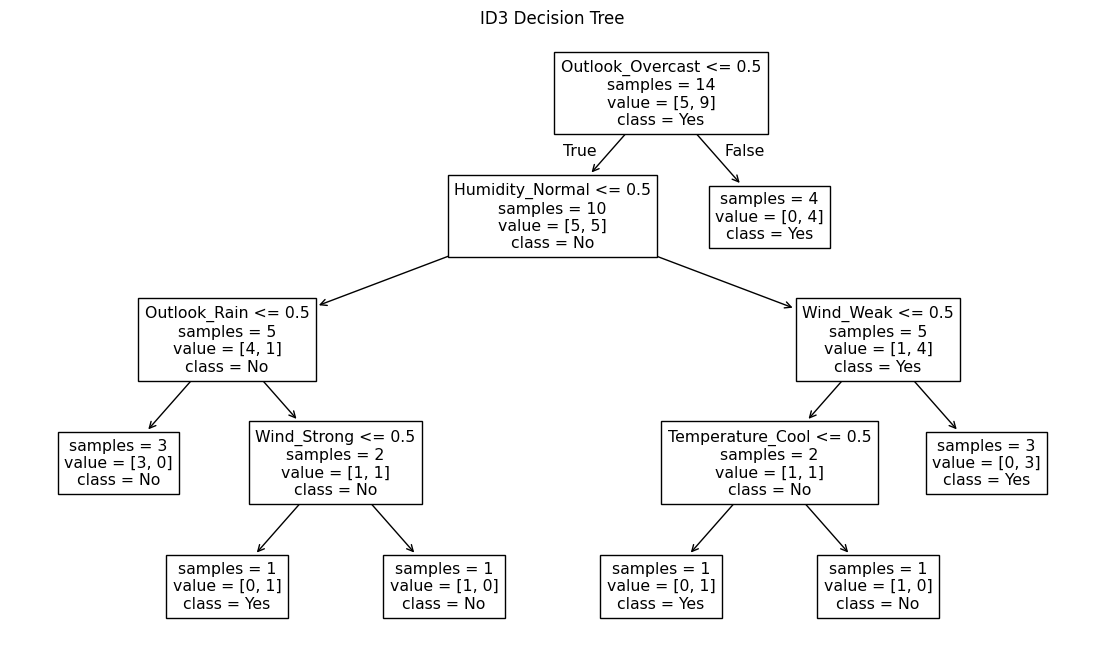

New Sample Prediction: Yes


In [10]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

data = {
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain',
                'Overcast','Sunny','Sunny','Rain','Sunny','Overcast',
                'Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool',
                    'Cool','Mild','Cool','Mild','Mild','Mild',
                    'Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal',
                 'Normal','High','Normal','Normal','Normal','High',
                 'Normal','High'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong',
             'Strong','Weak','Weak','Weak','Strong','Strong',
             'Weak','Strong'],
    'Play': ['No','No','Yes','Yes','Yes','No',
             'Yes','No','Yes','Yes','Yes','Yes',
             'Yes','No']
}

df = pd.DataFrame(data)

X = pd.get_dummies(df[['Outlook', 'Temperature', 'Humidity', 'Wind']])
y = df['Play'].map({'No': 0, 'Yes': 1})

model = DecisionTreeClassifier(criterion='entropy', random_state=0)
model.fit(X, y)

plt.figure(figsize=(14, 8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=False,
    rounded=False,
    impurity=False,
    proportion=False
)

plt.title("ID3 Decision Tree")
plt.show()
new_sample = pd.DataFrame({
    'Outlook': ['Sunny'],
    'Temperature': ['Cool'],
    'Humidity': ['Normal'],
    'Wind': ['Weak']
})

new_sample = pd.get_dummies(new_sample)
new_sample = new_sample.reindex(columns=X.columns, fill_value=0)

prediction = model.predict(new_sample)

print("New Sample Prediction:",
      "Yes" if prediction[0] == 1 else "No")